# A guide Portfolio Optimization Environment

This notebook aims to provide an example of using PortfolioOptimizationEnv (or POE) to train a reinforcement learning model that learns to solve the portfolio optimization problem.

In this document, we will reproduce a famous architecture called EIIE (ensemble of identical independent evaluators), introduced in the following paper:

- Zhengyao Jiang, Dixing Xu, & Jinjun Liang. (2017). A Deep Reinforcement Learning Framework for the Financial Portfolio Management Problem. https://doi.org/10.48550/arXiv.1706.10059.

It's advisable to read it to understand the algorithm implemented in this notebook.

### Note
If you're using this environment, consider citing the following paper (in adittion to FinRL references):

- Caio Costa, & Anna Costa (2023). POE: A General Portfolio Optimization Environment for FinRL. In *Anais do II Brazilian Workshop on Artificial Intelligence in Finance* (pp. 132–143). SBC. https://doi.org/10.5753/bwaif.2023.231144.

```
@inproceedings{bwaif,
 author = {Caio Costa and Anna Costa},
 title = {POE: A General Portfolio Optimization Environment for FinRL},
 booktitle = {Anais do II Brazilian Workshop on Artificial Intelligence in Finance},
 location = {João Pessoa/PB},
 year = {2023},
 keywords = {},
 issn = {0000-0000},
 pages = {132--143},
 publisher = {SBC},
 address = {Porto Alegre, RS, Brasil},
 doi = {10.5753/bwaif.2023.231144},
 url = {https://sol.sbc.org.br/index.php/bwaif/article/view/24959}
}

```

## Installation and imports

To run this notebook in google colab, uncomment the cells below.

In [1]:
# install finrl library
!sudo apt install swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

Password:
sudo: a password is required
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /private/var/folders/k3/x2ny3m2d3y57h8xp7cr2qxv80000gn/T/pip-req-build-o5gdxh96
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /private/var/folders/k3/x2ny3m2d3y57h8xp7cr2qxv80000gn/T/pip-req-build-o5gdxh96
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit e523ca0519288b3117f014e19163fe4c514d20ea
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /private/var/folders/k3/x2ny3m2d3y57h8xp7cr2qxv80000gn/T/pip-install-czq8ss7h/elegantrl_27536ba1fd5d4318b994fea8b16e1025
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /private/var/folders/k3/x2ny3m2d3y57h8xp7cr2qxv80000gn/T/pip-install-czq8ss7h/elegan

In [5]:
## We also need to install quantstats, because the environment uses it to plot graphs
!pip install quantstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.4 MB/s eta 0:00:00


In [2]:
## Hide matplotlib warnings
# import warnings
# warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

#### Import the necessary code libraries

In [119]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

## Fetch data

In his paper, *Jiang et al* creates a portfolio composed by the top-11 cryptocurrencies based on 30-days volume. Since it's not specified when this classification was done, it's difficult to reproduce, so we will use a similar approach in the Brazillian stock market:

- We select top-10 stocks from Brazillian stock market;
- For simplicity, we disconsider stocks that have missing data for the days in period 2011-01-01 to 2019-12-31 (9 years);

In [5]:
# TOP_BRL = [
#     "VALE3.SA", "PETR4.SA", "ITUB4.SA", "BBDC4.SA",
#     "BBAS3.SA", "RENT3.SA", "LREN3.SA", "PRIO3.SA",
#     "WEGE3.SA", "ABEV3.SA"
# ]

In [120]:
TOP_BRL =['000001.SS', '399001.SZ', '603000.SS']

In [121]:
print(len(TOP_BRL))

portfolio_raw_df = YahooDownloader(start_date = '2018-01-01',
                                end_date = '2024-10-22',
                                ticker_list = TOP_BRL).fetch_data()
portfolio_raw_df

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

3
Shape of DataFrame:  (4938, 8)


,date,open,high,low,close,volume,tic,day
0,2018-01-02,3314.031006,3349.052979,3314.031006,3348.325928,202300,000001.SS,1
1,2018-01-02,11079.639648,11178.049805,11072.870117,11178.005859,97900,399001.SZ,1
2,2018-01-02,10.830000,10.940000,10.830000,10.328034,4156350,603000.SS,1
3,2018-01-03,3347.742920,3379.915039,3345.289062,3369.107910,213800,000001.SS,2
4,2018-01-03,11181.179688,11316.459961,11171.120117,11280.255859,115500,399001.SZ,2
...,...,...,...,...,...,...,...,...
4933,2024-10-18,9868.849609,10607.809570,9865.870117,10357.679688,3433900,399001.SZ,4
4934,2024-10-18,21.110001,22.440001,20.879999,21.830000,41045845,603000.SS,4
4935,2024-10-21,3276.060059,3300.664062,3239.096924,3268.110107,668200,000001.SS,0
4936,2024-10-21,10441.870117,10636.160156,10331.790039,10470.910156,3212800,399001.SZ,0


In [122]:
portfolio_raw_df.groupby("tic").count()

,date,open,high,low,close,volume,day
tic,,,,,,,
000001.SS,1646,1646,1646,1646,1646,1646,1646
399001.SZ,1646,1646,1646,1646,1646,1646,1646
603000.SS,1646,1646,1646,1646,1646,1646,1646


In [123]:
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.config import INDICATORS
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_vix=True,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(portfolio_raw_df)

[*********************100%***********************]  1 of 1 completed

Successfully added technical indicators
Shape of DataFrame:  (1711, 8)
Successfully added vix


Successfully added turbulence index


In [124]:
import sys
# 添加环境路径
sys.path.append('/Users/pu17/Documents/stock/stock_price_prediction')
from feature.mysqlhandler import MySQLHandler
from config import OUTPUT_DIR
mysql_handler = MySQLHandler()
# 连接到数据库
mysql_handler.connect()
# 获取数据并重命名列
holiday_features = mysql_handler.fetch_table_as_dataframe('holiday_features_table').rename(columns={'trade_date': 'date'})
market_breadth = mysql_handler.fetch_table_as_dataframe('market_breadth_table').rename(columns={'trade_date': 'date'})
moneyflow_summary = mysql_handler.fetch_table_as_dataframe('moneyflow_summary_table').rename(columns={'trade_date': 'date'})

/Users/pu17/Documents/stock/stock_price_prediction/feature/mysqlhandler.py:268: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


In [125]:
moneyflow_summary = moneyflow_summary.drop(columns=[
    'buy_sm_vol', 'buy_sm_amount', 'sell_sm_vol', 'sell_sm_amount',
    'buy_md_vol', 'buy_md_amount', 'sell_md_vol', 'sell_md_amount',
    'buy_lg_vol', 'buy_lg_amount', 'sell_lg_vol', 'sell_lg_amount',
    'buy_elg_vol', 'buy_elg_amount', 'sell_elg_vol', 'sell_elg_amount'
])

In [126]:
market_breadth['date'] = market_breadth['date'].astype(str)
moneyflow_summary['date'] = moneyflow_summary['date'].astype(str)
holiday_features['date'] = holiday_features['date'].astype(str)
# 检查转换是否成功
print(processed['date'].dtype)
print(market_breadth['date'].dtype)
print(moneyflow_summary['date'].dtype)
print(holiday_features['date'].dtype)

object
object
object
object


In [127]:
holiday_features.head()

,date,day,spring_festival_pre_holiday,spring_festival_post_holiday,labor_day_pre_holiday,labor_day_post_holiday,national_day_pre_holiday,national_day_post_holiday,dayofmonth,dayofyear
0,2024-10-21,0,0,0,0,0,0,10,21,295
1,2024-10-18,4,0,0,0,0,0,9,18,292
2,2024-10-17,3,0,0,0,0,0,8,17,291
3,2024-10-16,2,0,0,0,0,0,7,16,290
4,2024-10-15,1,0,0,0,0,0,6,15,289


In [128]:
import pandas as pd
def select_exchange(row):
    if row['tic'] == '399001.SZ':
        return 'SZSE'
    elif row['tic'] in ['000001.SS', '603000.SS']:
        return 'SSE'
    return None

# 为 df1 添加一个新列 'exchange'，根据 'tic' 来选择合适的交易所
processed['exchange'] = processed.apply(select_exchange, axis=1)
holiday_features.drop(columns=['day'], inplace=True)

# 3. 左连接，基于 'date' 和 'exchange' 进行合并
processed = pd.merge(processed, market_breadth, how='left', on=['date', 'exchange'])

processed = pd.merge(processed, moneyflow_summary, how='left', on=['date', 'exchange'])
merged_df = pd.merge(processed, holiday_features, how='left', on='date')


In [129]:
portfolio_raw_df=merged_df.drop(columns=['exchange'])
portfolio_raw_df.head()

,date,open,high,low,close,volume,tic,day,macd,boll_ub,...,net_lg_pct,net_elg_pct,spring_festival_pre_holiday,spring_festival_post_holiday,labor_day_pre_holiday,labor_day_post_holiday,national_day_pre_holiday,national_day_post_holiday,dayofmonth,dayofyear
0,2018-01-02,3314.031006,3349.052979,3314.031006,3348.325928,202300,000001.SS,1,0.000000,3388.107080,...,0.000106,0.012361,0,0,0,0,0,0,2,2
1,2018-01-02,11079.639648,11178.049805,11072.870117,11178.005859,97900,399001.SZ,1,0.000000,3388.107080,...,-0.008774,0.009917,0,0,0,0,0,0,2,2
2,2018-01-02,10.830000,10.940000,10.830000,10.328034,4156350,603000.SS,1,0.000000,3388.107080,...,0.000106,0.012361,0,0,0,0,0,0,2,2
3,2018-01-03,3347.742920,3379.915039,3345.289062,3369.107910,213800,000001.SS,2,0.466262,3388.107080,...,-0.004923,0.000916,0,0,0,0,0,0,3,3
4,2018-01-03,11181.179688,11316.459961,11171.120117,11280.255859,115500,399001.SZ,2,2.294071,11373.734196,...,0.004139,0.013860,0,0,0,0,0,0,3,3


### Normalize Data

We normalize the data dividing the time series of each stock by its maximum value, so that the dataframe contains values between 0 and 1.

In [130]:
portfolio_norm_df = GroupByScaler(by="tic", scaler=MaxAbsScaler).fit_transform(portfolio_raw_df)
portfolio_norm_df

/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.15401599 0.16277122 0.15759421 ... 0.39269128 0.40243624 0.52759802]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(
/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.25 0.5  0.75 ... 0.5  0.75 1.  ]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(
/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preproce

,date,open,high,low,close,volume,tic,day,macd,boll_ub,...,net_lg_pct,net_elg_pct,spring_festival_pre_holiday,spring_festival_post_holiday,labor_day_pre_holiday,labor_day_post_holiday,national_day_pre_holiday,national_day_post_holiday,dayofmonth,dayofyear
0,2018-01-02,0.890608,0.897464,0.897426,0.901209,0.154016,000001.SS,0.25,0.000000,0.901426,...,0.001732,0.181446,0.0,0.0,0.0,0.0,0.0,0.000000,0.064516,0.005464
1,2018-01-02,0.680736,0.686061,0.705381,0.700278,0.017680,399001.SZ,0.25,0.000000,0.208048,...,-0.124275,0.131734,0.0,0.0,0.0,0.0,0.0,0.000000,0.064516,0.005464
2,2018-01-02,0.266486,0.255906,0.274177,0.247240,0.024267,603000.SS,0.25,0.000000,1.000000,...,0.001732,0.181446,0.0,0.0,0.0,0.0,0.0,0.000000,0.064516,0.005464
3,2018-01-03,0.899668,0.905734,0.905890,0.906803,0.162771,000001.SS,0.50,0.003381,0.901426,...,-0.080141,0.013447,0.0,0.0,0.0,0.0,0.0,0.000000,0.096774,0.008197
4,2018-01-03,0.686974,0.694556,0.711640,0.706683,0.020859,399001.SZ,0.50,0.003189,0.698408,...,0.058619,0.184105,0.0,0.0,0.0,0.0,0.0,0.000000,0.096774,0.008197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4762,2024-10-17,0.616516,0.621320,0.629897,0.619697,0.427599,399001.SZ,0.75,0.703927,0.708367,...,-0.297227,-0.094282,0.0,0.0,0.0,0.0,0.0,0.266667,0.548387,0.795082
4763,2024-10-17,0.536171,0.514620,0.539747,0.510853,0.153915,603000.SS,0.75,0.196177,0.007412,...,-0.104560,-0.128641,0.0,0.0,0.0,0.0,0.0,0.266667,0.548387,0.795082
4764,2024-10-18,0.850820,0.888064,0.853771,0.877857,0.527598,000001.SS,1.00,0.806296,0.947684,...,-0.094532,0.252455,0.0,0.0,0.0,0.0,0.0,0.300000,0.580645,0.797814
4765,2024-10-18,0.606344,0.651062,0.628491,0.648886,0.620151,399001.SZ,1.00,0.708765,0.714225,...,-0.073035,0.248309,0.0,0.0,0.0,0.0,0.0,0.300000,0.580645,0.797814


In [131]:
columns = portfolio_norm_df.columns
print(columns)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'up_count', 'down_count',
       'up_down_ratio', 'market_breadth', 'net_mf_vol', 'net_mf_amount',
       'net_sm_vol', 'net_sm_amount', 'net_md_vol', 'net_md_amount',
       'net_lg_vol', 'net_lg_amount', 'net_elg_vol', 'net_elg_amount',
       'net_sm_pct', 'net_md_pct', 'net_lg_pct', 'net_elg_pct',
       'spring_festival_pre_holiday', 'spring_festival_post_holiday',
       'labor_day_pre_holiday', 'labor_day_post_holiday',
       'national_day_pre_holiday', 'national_day_post_holiday', 'dayofmonth',
       'dayofyear'],
      dtype='object')


In [190]:
df_portfolio = portfolio_norm_df[["date", "tic", "close", "high", "low","volume"]]
df_portfolio=portfolio_norm_df
df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2018-01-01") & (df_portfolio["date"] < "2022-12-31")]
# df_portfolio_2020 = df_portfolio[(df_portfolio["date"] >= "2020-01-01") & (df_portfolio["date"] < "2020-12-31")]
# df_portfolio_2021 = df_portfolio[(df_portfolio["date"] >= "2021-01-01") & (df_portfolio["date"] < "2021-12-31")]
df_portfolio_2023 = df_portfolio[(df_portfolio["date"] >= "2023-01-01") & (df_portfolio["date"] < "2023-12-31")]
df_portfolio_2024 = df_portfolio[(df_portfolio["date"] >= "2024-01-01") & (df_portfolio["date"] < "2024-10-22")]

### Instantiate Environment

Using the `PortfolioOptimizationEnv`, it's easy to instantiate a portfolio optimization environment for reinforcement learning agents. In the example below, we use the dataframe created before to start an environment.

In [191]:
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=50,
        features=["close", "high", "low"],
        normalize_df=None
    )

### Instantiate Model

Now, we can instantiate the model using FinRL API. In this example, we are going to use the EIIE architecture introduced by Jiang et. al.

:exclamation: **Note:** Remember to set the architecture's `time_window` parameter with the same value of the environment's `time_window`.

In [214]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": 0.001,
    "policy": EIIE,
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": 3,
    "time_window": 50,
    "initial_features":3
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)

### Train Model

In [146]:
print(df_portfolio_train.shape)

(3519, 44)


In [216]:
DRLAgent.train_model(model, episodes=60)

  0%|          | 0/60 [00:00<?, ?it/s]

Initial portfolio value:100000
Final portfolio value: 353208.59375
Final accumulative portfolio value: 3.5320859375
Maximum DrawDown: -0.4891885915053298
Sharpe ratio: 0.8399556526578872


  2%|▏         | 1/60 [00:03<03:43,  3.78s/it]

Initial portfolio value:100000
Final portfolio value: 353692.6875
Final accumulative portfolio value: 3.536926875
Maximum DrawDown: -0.48925279229141594
Sharpe ratio: 0.8404645802036598


  3%|▎         | 2/60 [00:07<03:41,  3.82s/it]

...

 97%|█████████▋| 58/60 [03:11<00:06,  3.16s/it]

Initial portfolio value:100000
Final portfolio value: 381325.6875
Final accumulative portfolio value: 3.813256875
Maximum DrawDown: -0.491023954270283
Sharpe ratio: 0.8708679711198457


 98%|█████████▊| 59/60 [03:14<00:03,  3.28s/it]

Initial portfolio value:100000
Final portfolio value: 381743.4375
Final accumulative portfolio value: 3.817434375
Maximum DrawDown: -0.49103595651335397
Sharpe ratio: 0.8713724253381466


100%|██████████| 60/60 [03:18<00:00,  3.30s/it]


### Save Model

In [205]:
torch.save(model.train_policy.state_dict(), "policy_EIIE_my.pt")

## Test Model

### Instantiate different environments

Since we have three different periods of time, we need three different environments instantiated to simulate them.

In [206]:
environment_2023 = PortfolioOptimizationEnv(
    df_portfolio_2023,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

environment_2024 = PortfolioOptimizationEnv(
    df_portfolio_2024,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

### Test EIIE architecture
Now, we can test the EIIE architecture in the three different test periods. It's important no note that, in this code, we load the saved policy even though it's not necessary just to show how to save and load your model.

In [207]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2023": {},
    "2024": {}
}

# instantiate an architecture with the same arguments used in training
# and load with load_state_dict.
policy = EIIE(time_window=50, initial_features=3,device=device)
policy.load_state_dict(torch.load("policy_EIIE_my.pt"))

# 2021
DRLAgent.DRL_validation(model, environment_2023, policy=policy)
EIIE_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
DRLAgent.DRL_validation(model, environment_2024, policy=policy)
EIIE_results["2024"]["value"] = environment_2024._asset_memory["final"]
# 打印环境中保存的动作
print("Actions memory:",pd.DataFrame(environment_2024._actions_memory))

Initial portfolio value:100000
Final portfolio value: 138556.328125
Final accumulative portfolio value: 1.38556328125
Maximum DrawDown: -0.16992141778075065
Sharpe ratio: 1.5251776221028395
Initial portfolio value:100000
Final portfolio value: 99997.34375
Final accumulative portfolio value: 0.9999734375
Maximum DrawDown: -3.179687499998973e-05
Sharpe ratio: -1.5335786632129054
Actions memory:             0             1             2             3
0    1.000000  0.000000e+00  0.000000e+00  0.000000e+00
1    0.999142  5.107460e-07  7.482017e-04  1.091838e-04
2    0.999367  4.496671e-07  5.545864e-04  7.781616e-05
3    0.999507  3.894969e-07  4.399517e-04  5.296976e-05
4    0.999590  3.392277e-07  3.732936e-04  3.646484e-05
..        ...           ...           ...           ...
129  1.000000  2.227934e-15  2.443039e-09  2.569549e-07
130  1.000000  1.696605e-15  1.803031e-09  1.968767e-07
131  1.000000  6.415411e-16  8.288845e-10  1.039899e-07
132  1.000000  4.937421e-16  6.110529e-10  8

In [208]:
for i, action in enumerate(environment._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        print(f"Action at step {i}: {action}")

Action at step 0: [1. 0. 0. 0.]
Action at step 1: [0.         0.33333334 0.33333334 0.33333334]
Action at step 2: [0.         0.33333334 0.33333334 0.33333334]
Action at step 3: [0.         0.33333334 0.33333334 0.33333334]
Action at step 4: [0.         0.33333334 0.33333334 0.33333334]
Action at step 5: [0.         0.33333334 0.33333334 0.33333334]
Action at step 6: [0.         0.33333334 0.33333334 0.33333334]
Action at step 7: [0.         0.33333334 0.33333334 0.33333334]
Action at step 8: [0.         0.33333334 0.33333334 0.33333334]
Action at step 9: [0.         0.33333334 0.33333334 0.33333334]
Action at step 10: [0.         0.33333334 0.33333334 0.33333334]
Action at step 11: [0.         0.33333334 0.33333334 0.33333334]
Action at step 12: [0.         0.33333334 0.33333334 0.33333334]
Action at step 13: [0.         0.33333334 0.33333334 0.33333334]
Action at step 14: [0.         0.33333334 0.33333334 0.33333334]
Action at step 15: [0.         0.33333334 0.33333334 0.33333334]
Ac

### Test Uniform Buy and Hold
For comparison, we will also test the performance of a uniform buy and hold strategy. In this strategy, the portfolio has no remaining cash and the same percentage of money is allocated in each asset.

In [209]:
UBAH_results = {
    "train": {},
    # "2020": {},
    "2023": {},
    "2024": {}
}

PORTFOLIO_SIZE = len(TOP_BRL)

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]

# # 2020
# terminated = False
# environment_2020.reset()
# while not terminated:
#     action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
#     _, _, terminated, _ = environment_2020.step(action)
# UBAH_results["2020"]["value"] = environment_2020._asset_memory["final"]

# 2021
terminated = False
environment_2023.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2023.step(action)
UBAH_results["2023"]["value"] = environment_2023._asset_memory["final"]

# 2022
terminated = False
environment_2024.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2024.step(action)
UBAH_results["2024"]["value"] = environment_2024._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 124675.84375
Final accumulative portfolio value: 1.2467584375
Maximum DrawDown: -0.3828833120510511
Sharpe ratio: 0.3160397658013084
Initial portfolio value:100000
Final portfolio value: 108888.703125
Final accumulative portfolio value: 1.08888703125
Maximum DrawDown: -0.19923848738246375
Sharpe ratio: 0.5636607308218252
Initial portfolio value:100000
Final portfolio value: 94911.8828125
Final accumulative portfolio value: 0.949118828125
Maximum DrawDown: -0.24937983224996052
Sharpe ratio: -0.16054756443551235


### Plot graphics

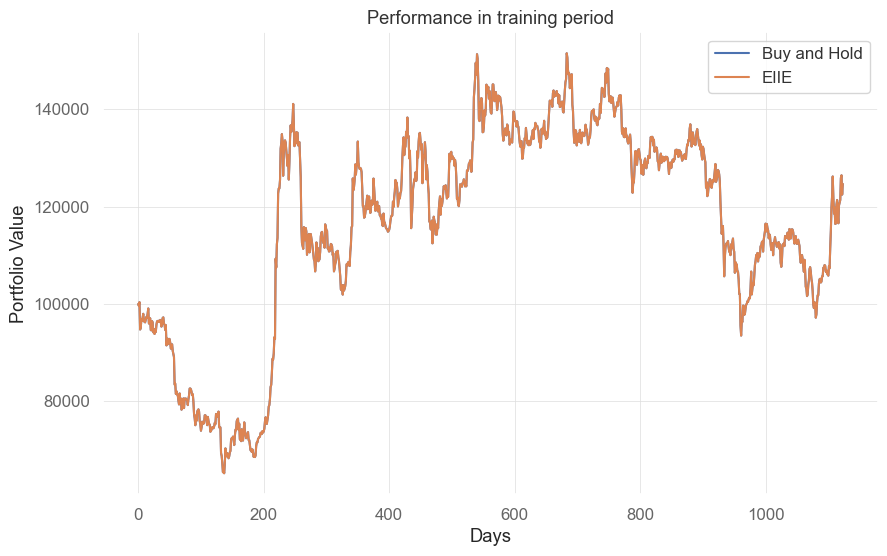

In [210]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["training"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()

plt.show()

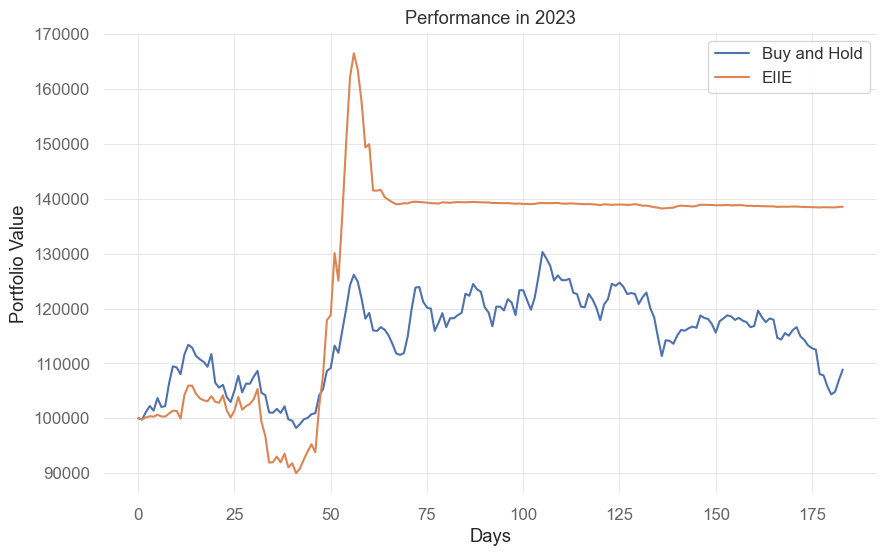

In [211]:
plt.plot(UBAH_results["2023"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2023"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2023")
plt.legend()

plt.show()

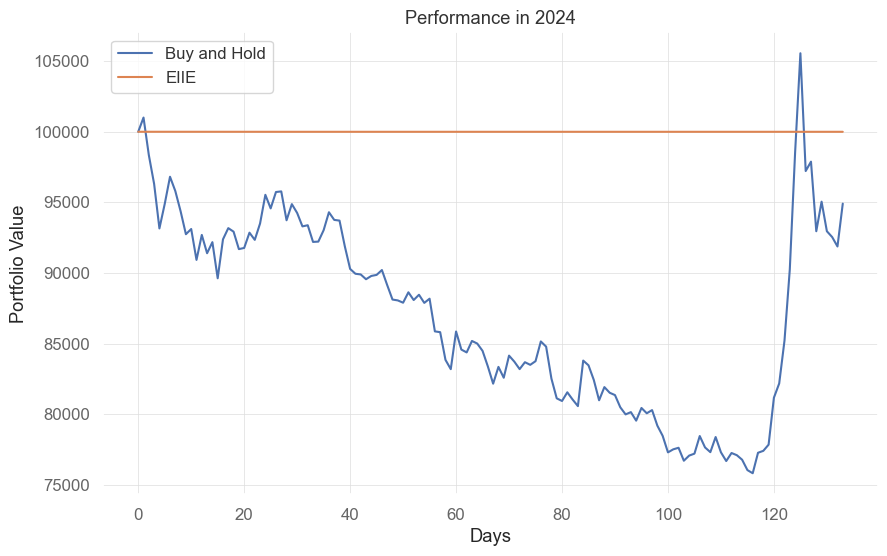

In [212]:
plt.plot(UBAH_results["2024"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2024"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2024")
plt.legend()

plt.show()

We can see that the agent is able to learn a good policy but its performance is worse the more the test period advances into the future. To get a better performance in 2022, for example, the agent should probably be trained again using more recent data.